<a href="https://colab.research.google.com/github/ridhoarte123/image-Filtering/blob/main/Image_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

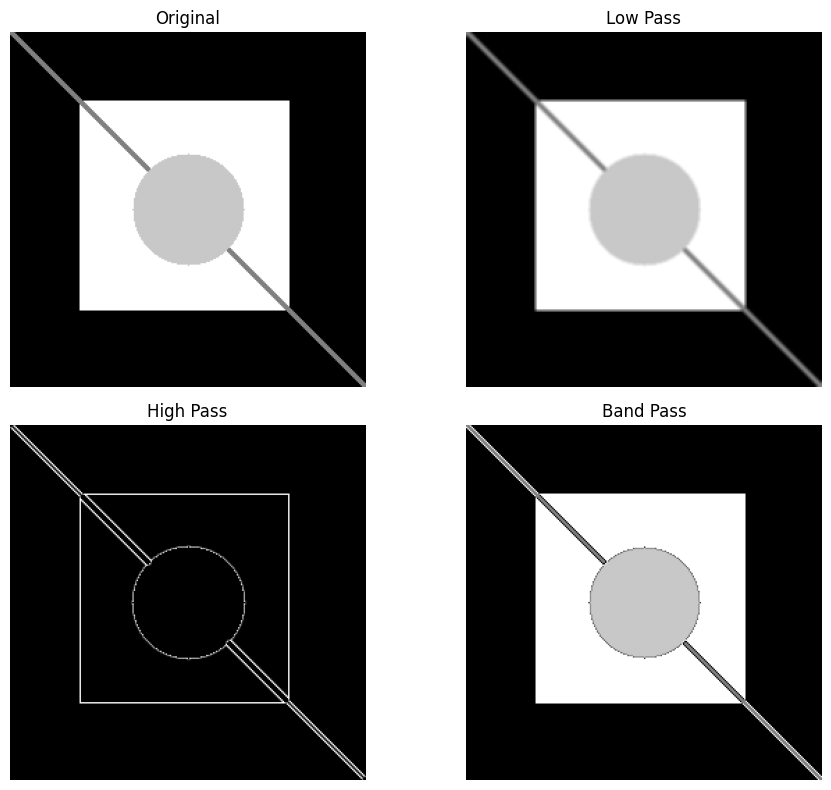

In [6]:
!pip install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# GAMBAR SINTETIS
# ==========================
img = np.zeros((256,256), dtype=np.uint8)

cv2.rectangle(img, (50,50), (200,200), 255, -1)
cv2.line(img, (0,0), (255,255), 128, 2)
cv2.circle(img, (128,128), 40, 200, -1)

# ==========================
# KERNEL FILTER
# ==========================
lpf = np.ones((3,3)) / 9

hpf = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
])

bpf = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

# ==========================
# KONVOLUSI
# ==========================
low = cv2.filter2D(img, -1, lpf)
high = cv2.filter2D(img, -1, hpf)
band = cv2.filter2D(img, -1, bpf)

# ==========================
# VISUALISASI
# ==========================
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(low, cmap='gray')
plt.title("Low Pass")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(high, cmap='gray')
plt.title("High Pass")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(band, cmap='gray')
plt.title("Band Pass")
plt.axis('off')

plt.tight_layout()
plt.show()

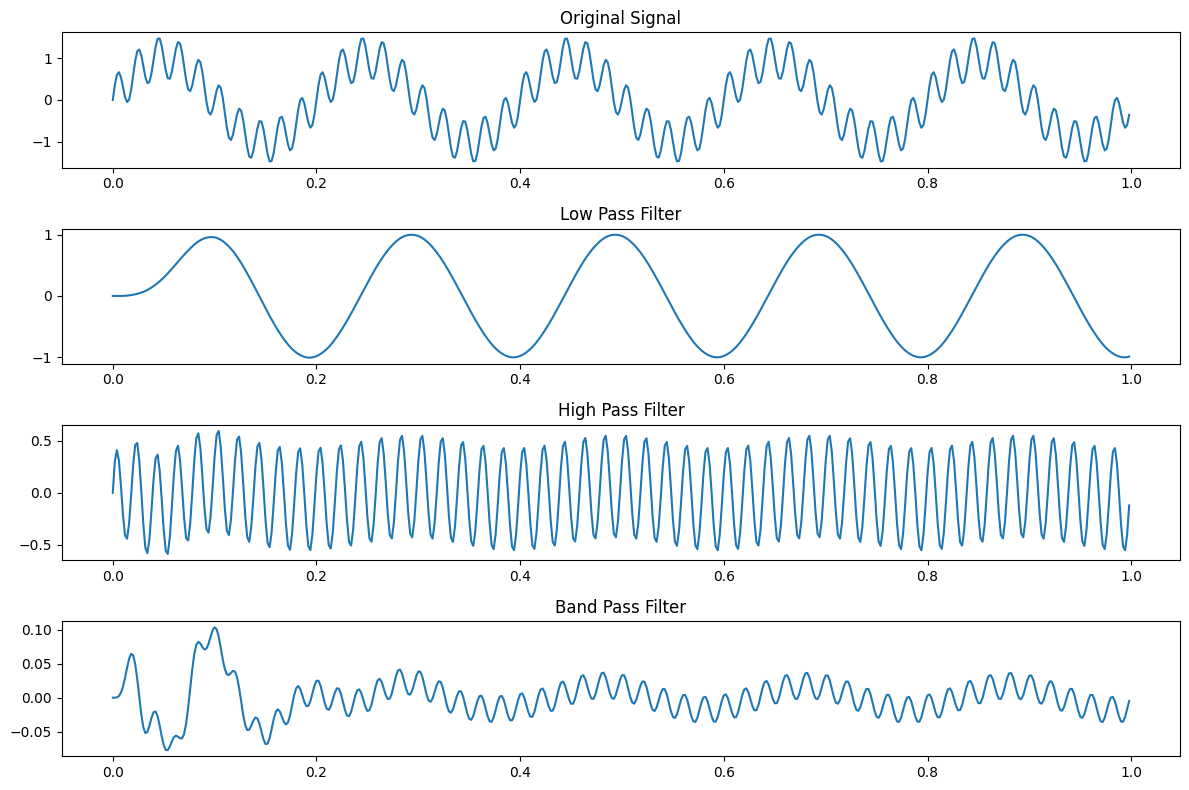

In [7]:
# ==========================
# IMPORT LIBRARY
# ==========================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# ==========================
# MEMBUAT SIGNAL CONTOH
# ==========================
fs = 500  # sampling frequency
t = np.linspace(0, 1, fs, endpoint=False)

# signal campuran (low + high frequency)
signal = np.sin(2*np.pi*5*t) + 0.5*np.sin(2*np.pi*50*t)

# ==========================
# FUNGSI FILTER
# ==========================
def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return b, a

def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high')
    return b, a

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

# ==========================
# APPLY FILTER
# ==========================
# Low-pass
b, a = butter_lowpass(10, fs)
low_filtered = lfilter(b, a, signal)

# High-pass
b, a = butter_highpass(10, fs)
high_filtered = lfilter(b, a, signal)

# Band-pass
b, a = butter_bandpass(10, 30, fs)
band_filtered = lfilter(b, a, signal)

# ==========================
# VISUALISASI
# ==========================
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(t, signal)
plt.title("Original Signal")

plt.subplot(4,1,2)
plt.plot(t, low_filtered)
plt.title("Low Pass Filter")

plt.subplot(4,1,3)
plt.plot(t, high_filtered)
plt.title("High Pass Filter")

plt.subplot(4,1,4)
plt.plot(t, band_filtered)
plt.title("Band Pass Filter")

plt.tight_layout()
plt.show()